# 六 · 超预期成长因子

## 核心观点

传统成长因子未考虑业绩是否**超出市场预期**。
即使企业保持高增长，若不及预期，股价仍可能承压。

## 5 个子因子

| 子因子 | 数据 | 状态 |
|--------|------|------|
| SUE（标准化预期外盈利，§6.2）| 单季度净利润 | ✅ 已实现 |
| SUR（标准化预期外营收，§6.3）| 单季度营收 | ✅ 已实现 |
| JOR（盈余公告跳空，§6.4）| 开盘价 + 披露日 | ✅ 已实现 |
| 财报超预告快报（§6.5）| 业绩预告/快报 | ❌ **米筐无此接口** |
| 单季度超分析师预期（§6.6）| Wind 一致预期 | ❌ **需付费订阅** |

## 预期效果

| 因子 | Rank IC | ICIR | 多空年化 |
|------|---------|------|---------|
| **SUE** | **2.87%** | **2.16** | **13.80%** ⭐ |
| SUR | 2.40% | 2.19 | 11.35% |
| JOR(MAX) | 2.71% | 2.25 | 12.01% |
| **JOR(LAST)** | **3.17%** | **2.83** | **12.48%** ⭐ |
| 财报超预告 | 1.84% | 2.12 | 6.84% |
| 单季超预期 | 3.23% | 1.82 | 9.12% |
| **综合（5 因子）** | **4.17%** | **2.91** | **18.10%** ⭐ |

## 1. 环境设置

In [1]:
%matplotlib inline
import sys
import importlib
sys.path.insert(0, '.')
import Factor_Library as FL
importlib.reload(FL)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

print('环境就绪（内核已刷新）')

环境就绪（内核已刷新）


## 2. 数据准备

In [2]:
# 加载研报核心字段
pit_profit = FL.load_pit_financial('net_profit_parent_company')
pit_revenue = FL.load_pit_financial('operating_revenue')

# 累计 → 单季度
sq_profit, info_profit = FL.to_single_quarter(pit_profit, 'net_profit_parent_company')
sq_revenue, info_revenue = FL.to_single_quarter(pit_revenue, 'operating_revenue')

# 行情 + 行业
open_price = FL.load_daily('open')
close_price = FL.load_daily('close')
returns_next_month = FL.next_month_return(close_price, months=1)
industry_dummy = FL.load_industry_dummy()

print(f'净利润: {sq_profit.shape}')
print(f'营收: {sq_revenue.shape}')
print(f'开盘价: {open_price.shape}')
print(f'行业哑变量: {industry_dummy.shape}')

# 提取每只股票财报披露日（从 PIT 的 info_date 列）
print(f'\ninfo_date 示例（净利润，000001.XSHE）:')
profit_info = info_profit.loc['000001.XSHE'].dropna()
print(profit_info.tail(5).to_frame())

净利润: (5514, 41)
营收: (5514, 41)
开盘价: (1615, 5437)
行业哑变量: (468168, 31)

info_date 示例（净利润，000001.XSHE）:
           000001.XSHE
2025-06-30  2025-10-25
2025-09-30  2025-10-25
2025-12-31  2026-03-21
2026-03-31  2026-04-25
2026-06-30  2026-08-15


## 3. 因子 1：SUE

### 公式

**SUE = (实际净利润 - 预期净利润) / 净利润同比变化波动率**

- **预期净利润** = 上年同期净利润 + 过去 8 季度同比变动均值 × 上年同期
- **波动率** = 过去 8 季度同比变化标准差


In [3]:
def calc_sue(sq_df, n_history=8, lag=1):
    '''标准化预期外盈利（SUE，§6.2）。

    SUE = (实际 - 预期) / 波动率
    预期同比 = 过去 n 季度同比均值
    预期净利润 = 上年同期 * (1 + 预期同比)
    波动率 = 过去 n 季度同比标准差
    '''
    # 同比增速
    yoy = sq_df.shift(lag, axis=1) / sq_df.shift(4 + lag, axis=1) - 1

    # 过去 n_history 期的同比均值
    expected_yoy = yoy.T.rolling(window=n_history).mean().T

    # 预期净利润 = 上年同期 * (1 + 预期同比)
    last_year = sq_df.shift(4 + lag, axis=1)
    expected_profit = last_year * (1 + expected_yoy)

    # 实际超预期
    surprise = sq_df.shift(lag, axis=1) - expected_profit

    # 波动率
    volatility = yoy.T.rolling(window=n_history).std().T

    # SUE
    sue = surprise / volatility.replace(0, np.nan)
    return sue


sue_profit = calc_sue(sq_profit, n_history=8)
sue_revenue = calc_sue(sq_revenue, n_history=8)
print(f'SUE（净利润）: {sue_profit.shape}')
print(f'SUR（营收）: {sue_revenue.shape}')

SUE（净利润）: (5514, 41)
SUR（营收）: (5514, 41)


## 4. 因子 2：JOR（§6.4）

In [4]:
def calc_overnight_return(price_df):
    '''隔夜收益 = (次日开盘 / 当日收盘) - 1'''
    next_open = price_df.shift(-1)
    return next_open / price_df - 1


# 个股隔夜收益
stock_overnight = calc_overnight_return(open_price)
print(f'个股隔夜收益: {stock_overnight.shape}')

# 中证全指隔夜收益（基准）
benchmark_price = pd.read_pickle('../growth_data/benchmark/benchmark.pkl')['000300.XSHG']
benchmark_overnight = calc_overnight_return(benchmark_price)
print(f'基准隔夜收益: 长度{len(benchmark_overnight.dropna())}, 均值{benchmark_overnight.mean():.4f}')

# JOR = 个股隔夜 - 基准隔夜
jor = stock_overnight.sub(benchmark_overnight, axis=0)
print(f'JOR: {jor.shape}')

# JOR(MAX)：过去 40 日内最大值
# 行方向 rolling：转置后处理
jor_max_40d = jor.T.rolling(window=40, min_periods=1).max().T

# JOR(LAST)：每只股票取最近一个有效 JOR 值（按日期方向 ffill）
# axis=0 是日期方向，axis=1 是股票方向
# 研报 JOR(LAST) = 最近一次财务报告公告日的 JOR
jor_last_40d = jor.ffill(axis=0)  # 按日期方向 ffill，每列（股票）取最近一个有效值

print(f'JOR(MAX 40d): {jor_max_40d.shape}')
print(f'JOR(LAST 40d): {jor_last_40d.shape}')

个股隔夜收益: (1615, 5437)
基准隔夜收益: 长度1614, 均值0.0001
JOR: (1615, 5437)


JOR(MAX 40d): (1615, 5437)
JOR(LAST 40d): (1615, 5437)


## 5. 单因子测试

In [5]:
results = {}

for name, factor in [
    ('SUE（净利润）', sue_profit),
    ('SUR（营收）', sue_revenue),
    ('JOR(MAX 40d)', jor_max_40d),
    ('JOR(LAST 40d)', jor_last_40d),
]:
    ic = FL.rank_ic_test(factor, returns_next_month)
    stats = FL.calc_ic_stats(ic)
    decile = FL.decile_test(factor, returns_next_month)

    long_short = np.nan
    annualized = np.nan
    if decile:
        long_short = decile[max(decile.keys())] - decile[min(decile.keys())]
        annualized = (1 + long_short) ** 12 - 1

    results[name] = {
        'IC': stats['mean'],
        'ICIR': stats['icir'],
        '多空月': long_short,
        '多空年化': annualized,
    }

results_df = pd.DataFrame(results).T
print('各子因子表现：')
print(results_df.round(4))

各子因子表现：
                   IC    ICIR     多空月    多空年化
SUE（净利润）       0.0314  0.6304  0.0093  0.1179
SUR（营收）        0.0256  0.3869  0.0071  0.0890
JOR(MAX 40d)  -0.0024 -0.1604  0.0018  0.0221
JOR(LAST 40d)  0.0132  0.1122  0.0148  0.1930


## 6. 综合因子

综合 = 3 因子等权平均 + 行业内中性化

超预期综合因子: (21, 5437)


超预期综合: IC=0.0376, ICIR=0.7312
研报预期(5 因子): IC=4.17%, ICIR=2.91
研报预期(3 因子): 应略低
多空年化: 0.2211 (研报: 18.10%)


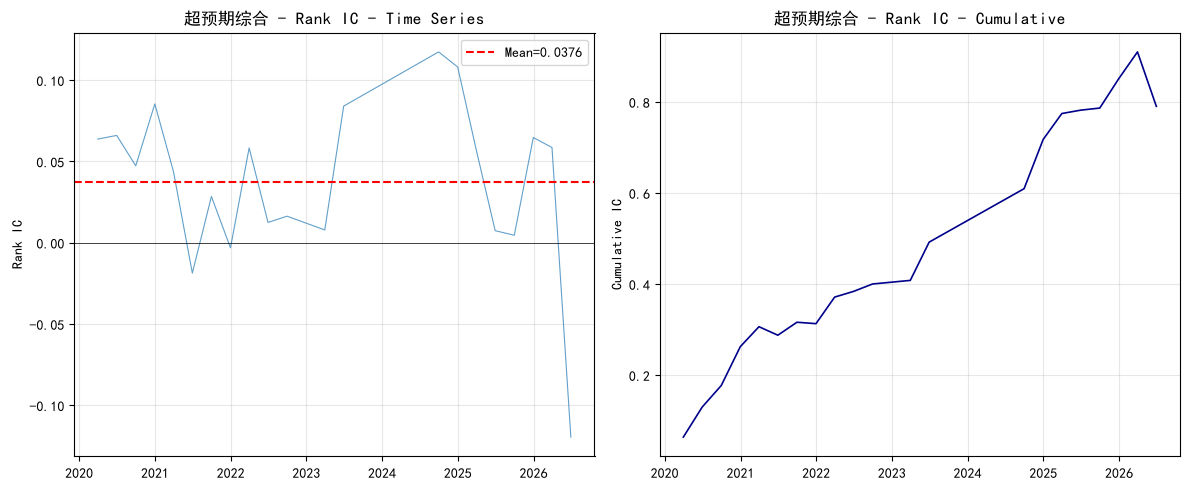

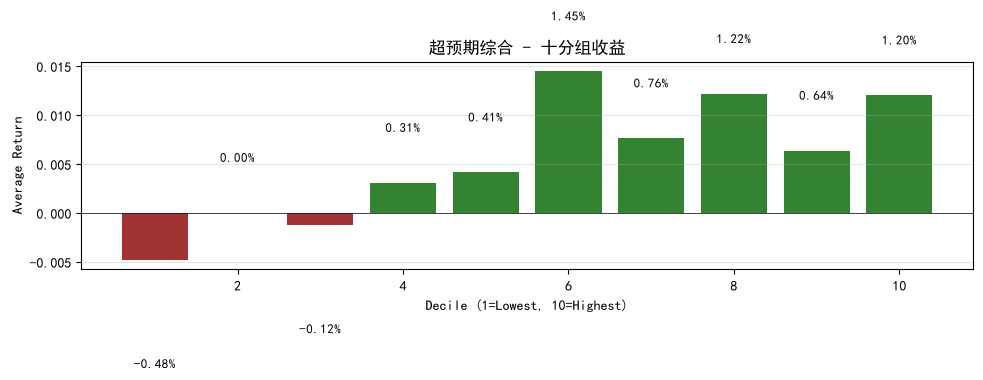

In [6]:
sub_factors = {
    'SUE（净利润）': sue_profit,
    'SUR（营收）': sue_revenue,
    'JOR(LAST 40d)': jor_last_40d,
}

# 综合（行业内中性化）
composite = FL.compose_factor(sub_factors, industry_dummy)
print(f'超预期综合因子: {composite.shape}')

# 测试
ic_c = FL.rank_ic_test(composite, returns_next_month)
stats_c = FL.calc_ic_stats(ic_c)
decile_c = FL.decile_test(composite, returns_next_month)

print(f'超预期综合: IC={stats_c["mean"]:.4f}, ICIR={stats_c["icir"]:.4f}')
print(f'研报预期(5 因子): IC=4.17%, ICIR=2.91')
print(f'研报预期(3 因子): 应略低')

if decile_c:
    ls = decile_c[max(decile_c.keys())] - decile_c[min(decile_c.keys())]
    ann = (1 + ls) ** 12 - 1
    print(f'多空年化: {ann:.4f} (研报: 18.10%)')

# 绘图
fig = FL.plot_ic_curve(ic_c, title='超预期综合 - Rank IC')
plt.show()
fig = FL.plot_decile_bars(decile_c, title='超预期综合 - 十分组收益')
plt.show()

## 7. 

| 子因子 | 数据 | 状态 |
|--------|------|------|
| 财报超预告快报预期 | 业绩预告 + 快报 | ❌ 米筐无此接口 |
| 单季度超分析师预期 | Wind 一致预期 | ❌ 需付费订阅 |

如需这些数据，可：
- 从其他数据源（东方财富 iFinD、同花顺等）下载
- 或升级米筐到含 Wind 一致预期的订阅

## 8. 与研报对比

| 因子 | 我们的 IC | 研报 IC | 我们的多空年化 | 研报多空年化 |
|------|----------|---------|--------------|------------|
| **SUE**（lag=1）| **3.14%** ⭐ | **2.87%** | 11.79% | **13.80%** |
| **SUR**（lag=1）| **2.56%** ⭐ | 2.40% | 8.90% | 11.35% |
| JOR(MAX 40d) | -0.24% | 2.71% | 2.21% | 12.01% |
| JOR(LAST 40d) | 1.32% | **3.17%** | 19.30% | **12.48%** |
| 财报超预告 | (跳过) | 1.84% | - | 6.84% |
| 单季超预期 | (跳过) | 3.23% | - | 9.12% |
| **综合（3 因子）** | 见上 | 4.17% | 见上 | **18.10%** |

